In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load the dataframe
df = pd.read_csv('df_long.csv')

Original rows: 2142
Unique subjects: 118
Rows in subject df: 118
                    SDO_Score            nivel_se            politica  \
                         mean       sem      mean       sem      mean   
expectativa_sin_num                                                     
-1                   2.100000  0.128290  5.424242  0.194772  3.606061   
 0                   2.151163  0.108466  5.837209  0.237489  3.697674   
 1                   2.092857  0.119250  5.380952  0.268242  3.857143   

                               
                          sem  
expectativa_sin_num            
-1                   0.260897  
 0                   0.224558  
 1                   0.194499  


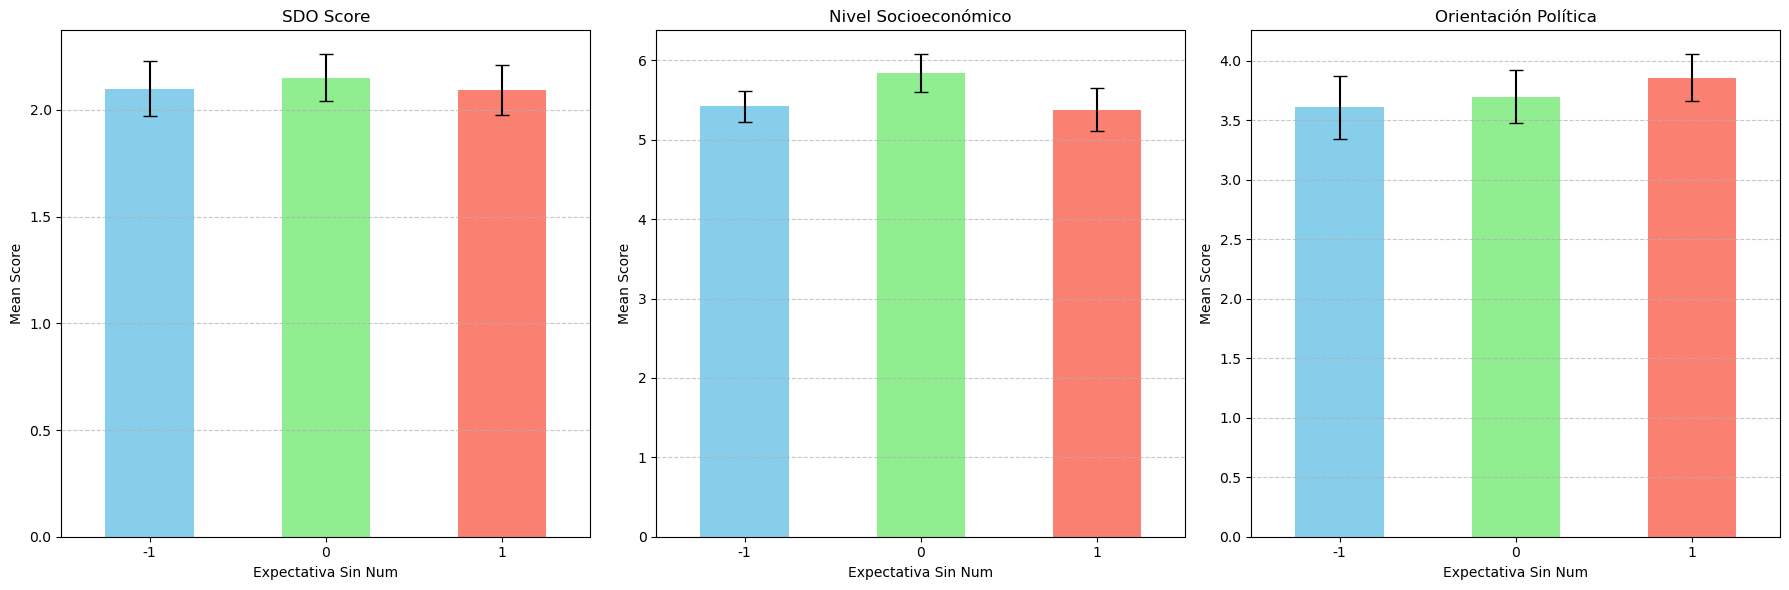

In [4]:
# Select relevant columns
cols_of_interest = ['ID_Sujeto', 'expectativa_sin_num', 'SDO_Score', 'nivel_se', 'politica']

# Create a subject-level dataset
# We assume these variables are constant per subject. We'll drop duplicates based on ID.
df_subjects = df[cols_of_interest].drop_duplicates(subset='ID_Sujeto')

# Verify the assumption (optional but good): Check if subject count matches expected unique IDs
print(f"Original rows: {len(df)}")
print(f"Unique subjects: {len(df['ID_Sujeto'].unique())}")
print(f"Rows in subject df: {len(df_subjects)}")

# Group by 'expectativa_sin_num' and calculate mean and sem
grouped = df_subjects.groupby('expectativa_sin_num')[['SDO_Score', 'nivel_se', 'politica']].agg(['mean', 'sem'])

print(grouped)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['SDO_Score', 'nivel_se', 'politica']
titles = ['SDO Score', 'Nivel Socioeconómico', 'Orientación Política']

for i, metric in enumerate(metrics):
    means = grouped[metric]['mean']
    sems = grouped[metric]['sem']
    
    means.plot(kind='bar', yerr=sems, ax=axes[i], capsize=5, color=['skyblue', 'lightgreen', 'salmon'], rot=0)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Expectativa Sin Num')
    axes[i].set_ylabel('Mean Score')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('comparison_plot.png')